### Explainability
We want to answers three questions:

- Which features mattered most? → Feature importance.
- How does the model behave overall? → SHAP summary plot.
- Why did it make this prediction? → SHAP waterfall plot.

### STEP 1 — Import Libraries

In [2]:
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)

# Load the Best Model
MODEL_DIR = os.path.join("..", "models")

model = joblib.load(
    os.path.join(
        MODEL_DIR,
        "terranova_disaster_cost_model.pkl"
    )
)

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['designated_area_count',
                                                   'declaration_delay_days',
                                                   'ongoing_at_declaration',
                                                   'declaration_year',
                                                   'declaration_month',
                                                   'declaration_weekday',
                                                   'previous_state_disasters',
                                       

In [3]:
# step 1b - Load the Feature Dataset
DATA_PROCESSED = os.path.join("..", "data", "processed")

df = pd.read_csv(
    os.path.join(
        DATA_PROCESSED,
        "features_terranova.csv"
    ),
    parse_dates=["declarationdate"]
)

In [4]:
# step 1c - Prepare the Data

FEATURE_COLS = [
    "state",
    "declarationtype",
    "incidenttype",
    "designated_area_count",
    "declaration_delay_days",
    "ongoing_at_declaration",
    "declaration_year",
    "declaration_month",
    "declaration_weekday",
    "declaration_season",
    "previous_state_disasters",
    "previous_incident_disasters",
    "previous_state_incident_disasters",
    "days_since_previous_state_disaster",
    "days_since_previous_incident"
]

# Sort chronologically.

df = df.sort_values("declarationdate")

In [5]:
# step 1d -Remove zero-cost disasters 

df = df[
    df["totalobligated"] > 0
].copy()

# Create the split.

split = int(len(df) * 0.80)

test_df = df.iloc[split:]

X_test = test_df[FEATURE_COLS]

### STEP 2 — Global Feature Importance

In [6]:
# step 2a - get feature names
feature_names = (
    model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = (
    model.named_steps["model"]
    .feature_importances_
)

# step 2b - Create a table.

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })
    .sort_values(
        "Importance",
        ascending=False
    )
)

# step 2c - Clean feature names.

importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("numeric__", "")
    .str.replace("categorical__", "")
)

# Display

importance_df.head(15)

,Feature,Importance
68,cat__declarationtype_DR,0.121760
70,cat__incidenttype_Biological,0.116559
16,cat__state_CA,0.072159
2,num__ongoing_at_declaration,0.068958
81,cat__incidenttype_Other,0.037511
83,cat__incidenttype_Severe Storm,0.034518
49,cat__state_NY,0.028182
41,cat__state_MT,0.026603
0,num__designated_area_count,0.024690
79,cat__incidenttype_Hurricane,0.019310


### STEP 3 — Plot Top Features

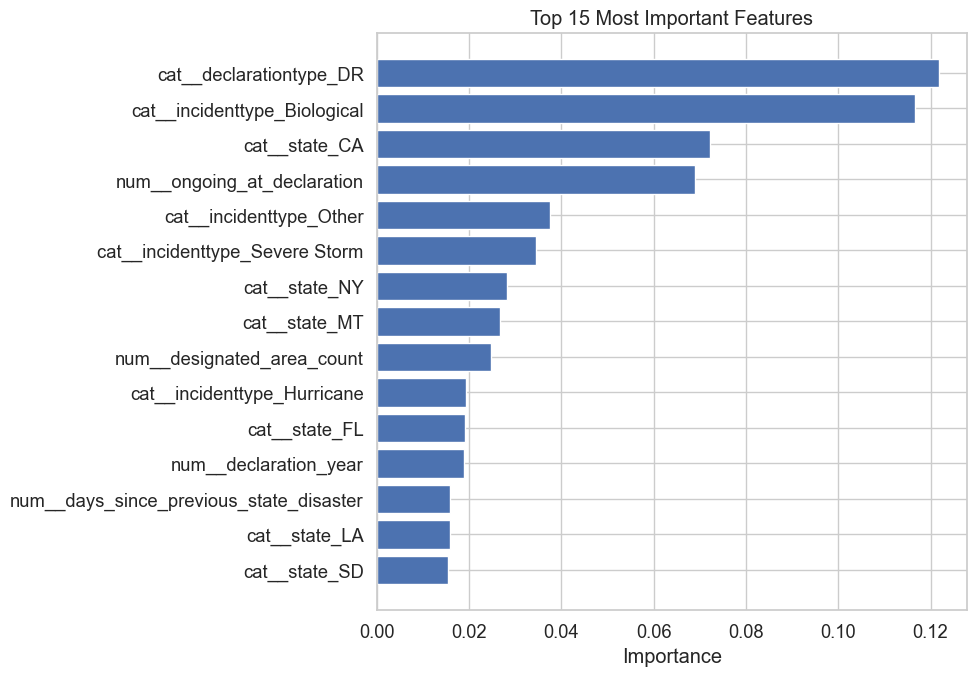

In [7]:

top_features = (
    importance_df
    .head(15)
    .sort_values("Importance")
)
plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Most Important Features")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()


### STEP 4 — SHAP Explainability


In [9]:

# step 4a - Transform the test data using the fitted preprocessor.

X_test_processed = (
    model.named_steps["preprocessor"]
    .transform(X_test)
)

# step 4b - Create the SHAP explainer.

explainer = shap.TreeExplainer(
    model.named_steps["model"]
)

# step 4c - Calculate SHAP values.

shap_values = explainer.shap_values(
    X_test_processed
)

### STEP 5 — SHAP Summary Plot

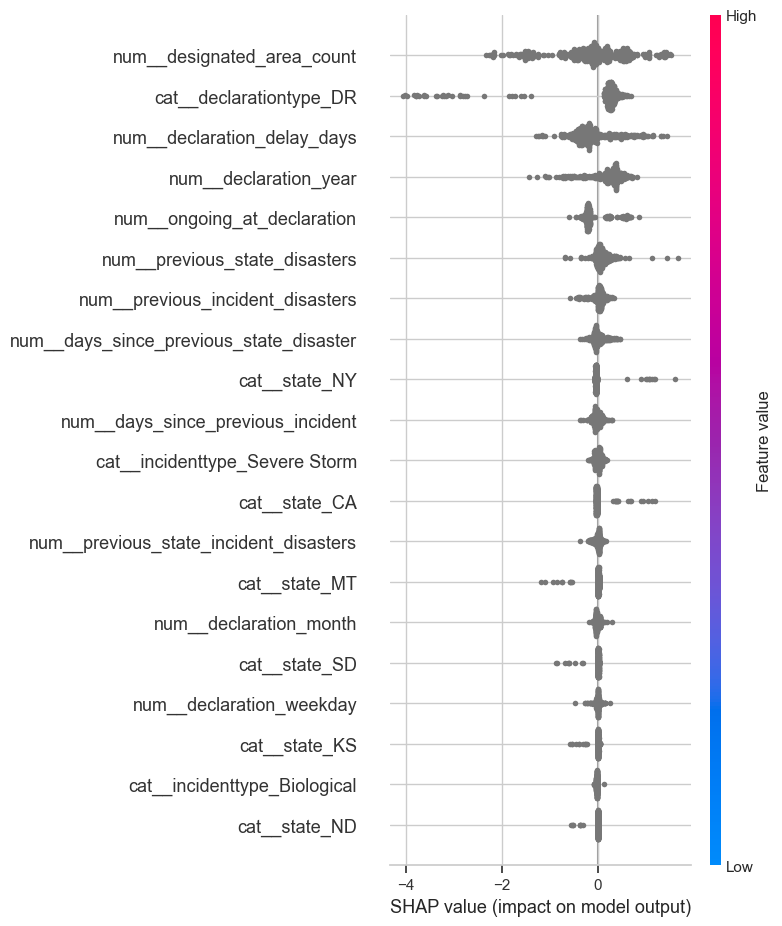

In [10]:
# which features matter most overall,
# whether high or low feature values increase predicted recovery cost.

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

### STEP 6 -  Explain One Disaster

- Choose one disaster from the test set.

- This explains exactly why the model predicted a high (or low) recovery cost for one disaster.

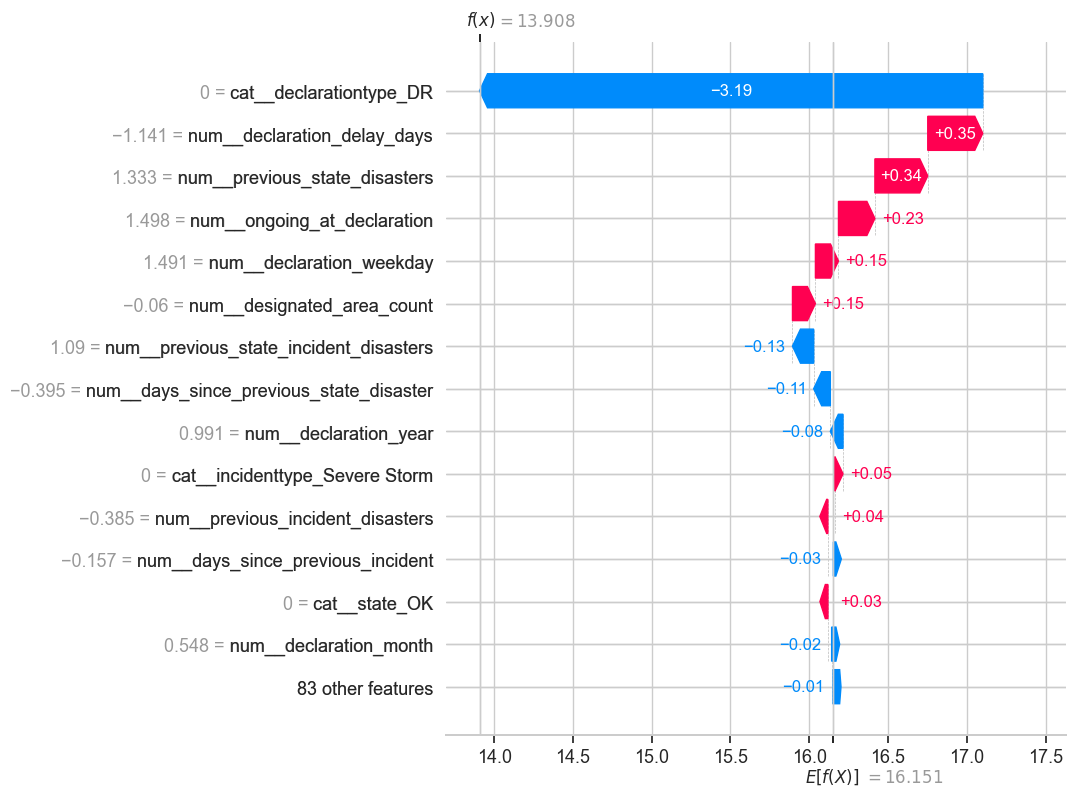

In [12]:
# Select one disaster
disaster_index = 5

# Convert the selected processed row from sparse to a 1D dense array
disaster_data = X_test_processed[disaster_index].toarray().flatten()

# Make sure the base value is a single number
base_value = np.asarray(explainer.expected_value).flatten()[0]

# Create the SHAP explanation for one disaster
disaster_explanation = shap.Explanation(
    values=np.asarray(shap_values[disaster_index]).flatten(),
    base_values=base_value,
    data=disaster_data,
    feature_names=feature_names
)

# Create waterfall plot
shap.plots.waterfall(disaster_explanation, max_display=15)



### Key Findings


• XGBoost produced the best predictive performance.

• Geographic location was one of the strongest drivers of recovery cost.

• Certain disaster types consistently increased predicted recovery costs.

• Larger designated disaster areas generally resulted in higher predicted recovery costs.

• Historical disaster frequency also influenced the model's predictions.

• SHAP analysis confirmed that the model's decisions were based on multiple declaration-stage characteristics rather than a single variable.